In [15]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from DATA_CHECK import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 




In [16]:
def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (2*del_lam**2)) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    print(f'Del Lambda = {del_lam*1e8:.1f} Angstrom')
    # print('dlam',del_lam)
    EW =abs((F_max - Fc)/ Fc)*np.sqrt(np.pi*2)*del_lam  # dimension of lambda
    print(f'ratio of Peak and Continuum = {abs((F_max - Fc)/ Fc):.2e}')
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8

def find_fc(EW,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    a = EW/(np.sqrt(np.pi)*del_lam)
    Fc = F_max/(a+1)

    return Fc


In [17]:
Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
cloudy_path_440 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

Ryd, Fnu = QSO_SED(cloudy_path_440) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 
normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s

Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


Lc = 6e40 / 10**(0.5) # erg/s/A
# aa = np.argmax(Llambda[ii])
aa = np.where((lambda_cm >1548e-8) & (lambda_cm <= 1551e-8))[0]
lambda_A[aa[1]]

np.float64(1549.1475008516436)

Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
Continuum = 1.90e+40 erg/s/A
Peak = 3.47e+40 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1549.1475008516436 A
Equivalent Width = 32.20 Angstrom
Total Luminosity of QSO C IV = 6.11e+41 erg/s
Total Luminosity of Continuum at 1500-1600 A = 1.90e+42 erg/s
5.0574935746529027e+42


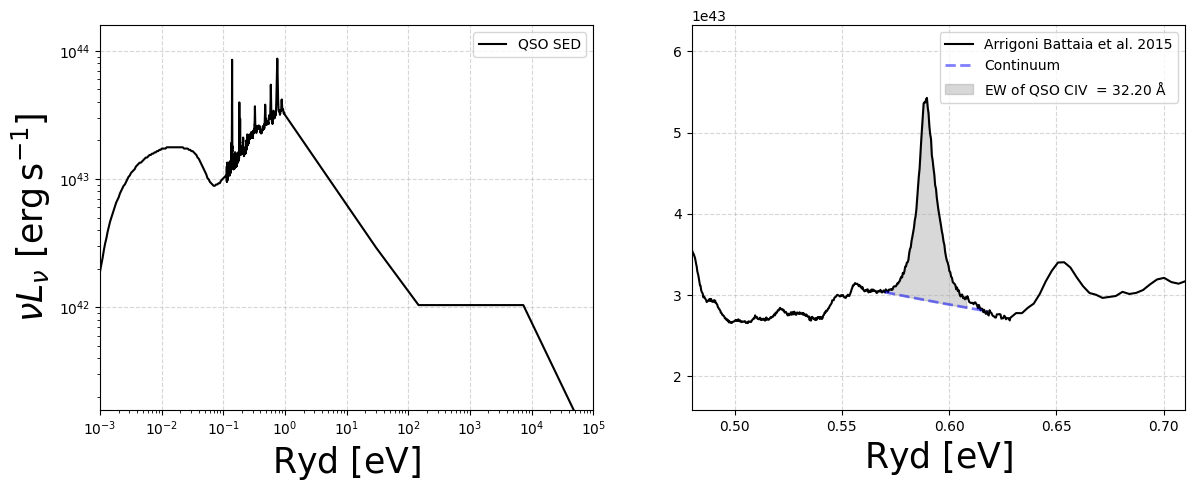

In [18]:
Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
cloudy_path_440 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

Ryd, Fnu = QSO_SED(cloudy_path_440) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 
normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


fig = plt.figure(1,figsize=(14,5))


plt.subplot(121)

Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


Lc = 6e40 / 10**(0.5) # erg/s/A
# aa = np.argmax(Llambda[ii])
aa = np.where((lambda_cm >1548e-8) & (lambda_cm <= 1551e-8))[0]
# lambda_A[aa[1]]

# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# # print(lambda_c)
# # lambda_c =(C_IV_K + C_IV_H)/2
# nu_c = c_cms / lambda_cm[ii[aa]] 

Llambda_max = Llambda[aa[1]] 
lambda_c = lambda_cm[aa[1]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[aa[1]] 

Ryd_c =nu_c / (13.6 /h_ev)


plt.plot(Ryd, nuLnu,'k-',label='QSO SED')
# plt.axvline(x=Ryd_c,ymin=0,ymax=1,linestyle='-',color='b',alpha=0.3,lw=3,label=r'C IV$\lambda1549$')

plt.legend(fontsize=10)

# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)

# plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)
plt.xlabel(r'Ryd $[ \rm eV]$',fontsize=25)
plt.ylabel(r'$\nu L_{\nu}~[\rm erg \, s^{-1}]$',fontsize=25)

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlim(xmin=1e-3,xmax=1e5)
plt.ylim(ymin=5e41/ 10**(0.5) ,ymax=5e44/ 10**(0.5) )


plt.xscale('log')
plt.yscale('log')




plt.subplot(122)
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


Lc = 6e40 / 10**(0.5)  # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# # print(lambda_c)
# # lambda_c =(C_IV_K + C_IV_H)/2
# nu_c = c_cms / lambda_cm[ii[aa]] 

aa = np.where((lambda_cm >1548e-8) & (lambda_cm <= 1551e-8))[0]
lambda_A[aa[1]]

Llambda_max = Llambda[aa[1]] 
lambda_c = lambda_cm[aa[1]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[aa[1]] 

Ryd_c =nu_c / (13.6 /h_ev)



# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

CIV_total_flux_QSO = ew*Lc #* nu_c
Lc_total_flux_QSO = Lc*   (1600-1500)  # erg/s #[min:max] of continuum


print(f'Continuum = {Lc:.2e} erg/s/A') 
print(f'Peak = {Llambda_max:.2e} erg/s/A') 
print(f'velocity dispersion = {sig_vel:.2e} km/s') 
print(f'lmabda_c = {lambda_c*1e8} A') 


print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Luminosity of QSO C IV = {CIV_total_flux_QSO:.2e} erg/s') 
print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO:.2e} erg/s') 


continuum_nuLnu = Lc * nu / (c_cms / (lambda_cm)**2 * 1e-8)

plt.plot(Ryd, nuLnu ,'k-',label='Arrigoni Battaia et al. 2015')
# plt.plot(Ryd,flux*nu /  (c_cms / (lambda_cm)**2 * 1e-8) ,'r--',label='Fitting')

# plt.axhline(y=Lc *nu_c / (c_cms / (lambda_c)**2 * 1e-8),xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')
lambda_min_A, lambda_max_A = 1500, 1600
lambda_min_cm = lambda_min_A * 1e-8
lambda_max_cm = lambda_max_A * 1e-8
Ryd_min = c_cms * h_ev / (lambda_max_cm * 13.6)
Ryd_max = c_cms * h_ev / (lambda_min_cm * 13.6)

Ryd_center= c_cms * h_ev / (1549e-8* 13.6)

# plt.axvline(x=Ryd_center,ymin=0,ymax=1,linestyle='-',color='b',alpha=0.3,lw=3,label=r'C IV$\lambda1549$')

tt = np.where((Ryd >= Ryd_min) & (Ryd <= Ryd_max+0.01))

aa = np.where((Ryd >= 4 - 1) & (Ryd <= 4+1))
civ_Ryd = 47.9/13.6
yy = ((continuum_nuLnu[aa][1] - continuum_nuLnu[aa][0]) / (Ryd[aa][1]-Ryd[aa][0]))*(civ_Ryd  - Ryd[aa][0]) +  continuum_nuLnu[aa][0]
print(yy)

plt.plot(Ryd[tt],continuum_nuLnu[tt],color='b',linestyle='--',lw=2,alpha=0.5,label='Continuum')

m = (Ryd >= Ryd_min) & (Ryd <= Ryd_max) & (nuLnu >= continuum_nuLnu)
plt.fill_between(
    Ryd,
    continuum_nuLnu,
    nuLnu,
    where=m,
    color='gray',
    alpha=0.3,
    interpolate=True,
    label=f'EW of QSO CIV  = {ew:.2f} $\\rm \\AA$'
)



plt.xlim(0.48,0.71)

# plt.yscale('log')
plt.ylim(ymin=5e43/ 10**(0.5) ,ymax=2e44/ 10**(0.5) )


# plt.axvline(x=Ryd_c,ymin=0,ymax=1,linestyle='-',color='b',alpha=0.7)


# plt.legend()

plt.xlabel(r'Ryd $[ \rm eV]$',fontsize=25)
# plt.ylabel(r'$L_{\nu}~[\rm erg \, s^{-1} \, Hz^{-1}]$',fontsize=25)


plt.legend()

# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

plt.grid(True,linestyle='--',alpha=0.5)

Lc_40 = 6e40  # erg/s/A
min_ratio = 0.1e41/Lc_40
max_ratio = 2e41/Lc_40
Lc_max_ratio = (Llambda_max-Lc)/ Lc
# min_ratio = 5e43 / Lc/ 10**(0.5)
# max_ratio = 2e44/Lc/ 10**(0.5)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED.pdf', bbox_inches='tight')

In [ ]:
# Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
# idx_2 = 2
# metals = 0.1 # 0.001 - 10.0
# Column_density_order = 22.0  # 18.0 - 25.0
# cloudy_path_440 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

# Ryd, Fnu = QSO_SED(cloudy_path_440) # [1/Hz]
# nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
# nuFnu = Fnu * nu # dimenionless parameter 
# normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s

# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


# Lc = 6e40 / 10**(0.5)  # erg/s/A
# aa = np.where((lambda_cm >1548e-8) & (lambda_cm <= 1551e-8))[0]
# lambda_A[aa[1]]

# Llambda_max = Llambda[aa[1]] 
# lambda_c = lambda_cm[aa[1]]
# nu_c = c_cms / lambda_cm[aa[1]] 

# Ryd_c =nu_c / (13.6 /h_ev)



# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A

# dlam = 0.001 # Amostrong
# xx = np.arange(1500,1600+dlam,dlam)

# # xx에 해당하는 lambda_cm (cm 단위)로 변환
# xx_cm = xx * 1e-8  # Angstrom to cm

# # lambda_cm에 대한 flux를 xx_cm에 대해 보간
# from scipy.interpolate import interp1d
# flux_interp_func = interp1d(lambda_cm, flux, kind='linear', bounds_error=False, fill_value=np.nan)
# flux_xx = flux_interp_func(xx_cm)

# print(f'Interpolated flux shape: {flux_xx.shape}')
# print(f'First few values: {flux_xx[:5]}')

# EW = np.sum(abs(flux_xx - Lc)/Lc *dlam)
# print(EW)

# # ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

# # CIV_total_flux_QSO = ew*Lc #* nu_c
# # Lc_total_flux_QSO = Lc*   (1600-1500)  # erg/s #[min:max] of continuum


# # print(f'Continuum = {Lc:.2e} erg/s/A') 
# # print(f'Peak = {Llambda_max:.2e} erg/s/A') 
# # print(f'velocity dispersion = {sig_vel:.2e} km/s') 
# # print(f'lmabda_c = {lambda_c*1e8} A') 


# # print(f'Equivalent Width = {ew:.2f} Angstrom')
# # print(f'Total Luminosity of QSO C IV = {CIV_total_flux_QSO:.2e} erg/s') 
# # print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO:.2e} erg/s') 


# # continuum_nuLnu = Lc * nu / (c_cms / (lambda_cm)**2 * 1e-8)

# # lambda_min_A, lambda_max_A = 1500, 1600
# # lambda_min_cm = lambda_min_A * 1e-8
# # lambda_max_cm = lambda_max_A * 1e-8
# # Ryd_min = c_cms * h_ev / (lambda_max_cm * 13.6)
# # Ryd_max = c_cms * h_ev / (lambda_min_cm * 13.6)

# # Ryd_center= c_cms * h_ev / (1549e-8* 13.6)



Interpolated flux shape: (100001,)
First few values: [1.90771352e+40 1.90771549e+40 1.90771746e+40 1.90771944e+40
 1.90772141e+40]
32.15814716514741


In [19]:
def make_parameter_SED(Lumin,ew_based):
    globals()[f'cloudy_path_{Lumin}'] = CLOUDY_path(Lumin,2,1.0,22.0)
    Ryd, Fnu = QSO_SED(globals()[f'cloudy_path_{Lumin}']) # [1/Hz]
    nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
    nuFnu = Fnu * nu # dimenionless parameter 
    normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s
    Lnu = Fnu*normalized_factor # erg/s/Hz
    nuLnu = Fnu*normalized_factor*nu # erg/s

    lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
    lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

    ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]
    Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


    # aa = np.argmax(Llambda[ii])
    # Llambda_max = Llambda[ii[aa]] 
    # lambda_c = lambda_cm[ii[aa]]
    # nu_c = c_cms / lambda_cm[ii[aa]] 

    aa = np.where((lambda_cm >1548e-8) & (lambda_cm <= 1551e-8))[0]

    Llambda_max = Llambda[aa[1]] 
    lambda_c = lambda_cm[aa[1]]

    nu_c = c_cms / lambda_cm[aa[1]] 

    Ryd_c =nu_c / (13.6 /h_ev)

    sig_vel = 3000 #km/s



    # Lc_max_ratio
    globals()[f'Lc_{Lumin}'] = Llambda_max/(Lc_max_ratio+1) #find_fc(ew_based,Llambda_max,lambda_c,sig_vel)# erg/s/A
    globals()[f'flux_{Lumin}'] = Flux(globals()[f'Lc_{Lumin}'],Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
    globals()[f'ew_{Lumin}'] = EW(globals()[f'Lc_{Lumin}'],Llambda_max,lambda_c,sig_vel)*1e8 # A


    globals()[f'CIV_total_flux_QSO_{Lumin}'] = globals()[f'ew_{Lumin}']*globals()[f'Lc_{Lumin}'] #* nu_c
    globals()[f'Lc_total_flux_QSO_{Lumin}'] = globals()[f'Lc_{Lumin}']*   (1600-1500)  # erg/s #[min:max] of continuum


    print(f'Continuum = { globals()[f"Lc_{Lumin}"]:.2e} erg/s/A') 
    print(f'Peak = {Llambda_max:.2e} erg/s/A') 
    print(f'velocity dispersion = {sig_vel:.2e} km/s') 
    print(f'lmabda_c = {lambda_c*1e8} A') 

    print(f'Equivalent Width = {globals()[f"ew_{Lumin}"]:.2f} Angstrom')
    print(f'Total Luminosity of QSO C IV = {globals()[f"CIV_total_flux_QSO_{Lumin}"]:.2e} erg/s')
    print(f'Total Luminosity of Continuum at 1500-1600 A = {globals()[f"Lc_total_flux_QSO_{Lumin}"]:.2e} erg/s')


    plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
    plt.plot(lambda_A,globals()[f'flux_{Lumin}'],'r--',label='Fitting')
    plt.axhline(y=globals()[f'Lc_{Lumin}'],xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label=f'Continuum = {globals()[f"Lc_{Lumin}"]:.2e} $\\rm [erg/s/\AA]$')

    # Shade area between Lc and Llambda for 1500–1600 Å where Llambda ≥ Lc
    m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= globals()[f'Lc_{Lumin}'])
    plt.fill_between(lambda_A, globals()[f'Lc_{Lumin}'], Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {globals()[f"ew_{Lumin}"]:.2f} $\\rm \AA$')

    plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
    plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

    plt.xlim(1400,1700)
    # min_ratio = 0.1e41/Lc
    # max_ratio = 2e41/Lc
    y_min = min_ratio * globals()[f'Lc_{Lumin}']
    y_max = max_ratio * globals()[f'Lc_{Lumin}']
    plt.ylim(ymin=y_min ,ymax=y_max)

    plt.legend()

    plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
    plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


    

    

Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
Continuum = 1.90e+40 erg/s/A
Peak = 3.47e+40 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1549.1475008516436 A
Equivalent Width = 32.20 Angstrom
Total Luminosity of QSO C IV = 6.11e+41 erg/s
Total Luminosity of Continuum at 1500-1600 A = 1.90e+42 erg/s


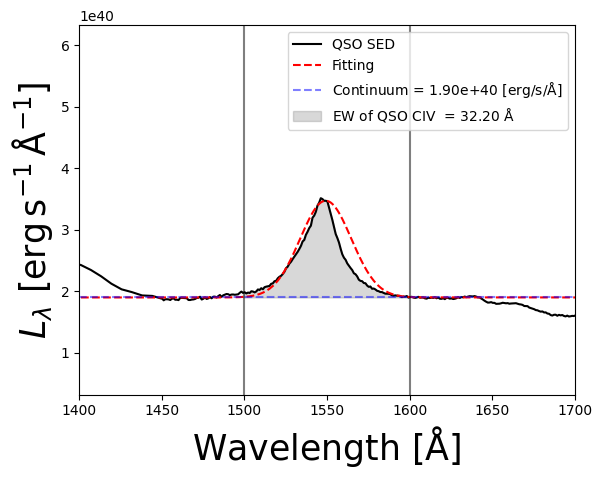

In [20]:
make_parameter_SED(43.5,ew)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_455_QSO', bbox_inches='tight')

In [21]:
def make_parameter_data(Lumin,ew_based):
    globals()[f'cloudy_path_{Lumin}'] = CLOUDY_path(Lumin,2,1.0,22.0)
    Ryd, Fnu = QSO_SED(globals()[f'cloudy_path_{Lumin}']) # [1/Hz]
    nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
    nuFnu = Fnu * nu # dimenionless parameter 
    normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s
    Lnu = Fnu*normalized_factor # erg/s/Hz
    nuLnu = Fnu*normalized_factor*nu # erg/s

    lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
    lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

    ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]
    Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


    aa = np.argmax(Llambda[ii])
    Llambda_max = Llambda[ii[aa]] 
    lambda_c = lambda_cm[ii[aa]]
    nu_c = c_cms / lambda_cm[ii[aa]] 
    sig_vel = 3000 #km/s


    # Lc_max_ratio
    globals()[f'Lc_{Lumin}'] = Llambda_max/(Lc_max_ratio+1) #find_fc(ew_based,Llambda_max,lambda_c,sig_vel)# erg/s/A
    globals()[f'flux_{Lumin}'] = Flux(globals()[f'Lc_{Lumin}'],Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
    globals()[f'ew_{Lumin}'] = EW(globals()[f'Lc_{Lumin}'],Llambda_max,lambda_c,sig_vel)*1e8 # A


    globals()[f'CIV_total_flux_QSO_{Lumin}'] = globals()[f'ew_{Lumin}']*globals()[f'Lc_{Lumin}'] #* nu_c
    globals()[f'Lc_total_flux_QSO_{Lumin}'] = globals()[f'Lc_{Lumin}']*   (1600-1500)  # erg/s #[min:max] of continuum

    y_min = min_ratio * globals()[f'Lc_{Lumin}']
    y_max = max_ratio * globals()[f'Lc_{Lumin}']

def make_parameter_geo(Lumin,idx,metals,Column_density_order,geo,V_out,V_emit,V_rand):
    make_parameter_data(Lumin,ew)
    # geo_t= 'Test'
    # V_emit = 1.0
    cloudy_path = CLOUDY_path(Lumin,idx,metals,Column_density_order)
    cloudy_data = CLOUDY_data_path(cloudy_path)


    globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'] = cloudy_data[f'radius_p'] , cloudy_data[f'SB_CIV']
    globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}']= cloudy_data[f'radius_p'] , cloudy_data[f'SB_HeII']
    
    atom ="CIV"

    path_RT = "/home/jin/RT/Data_metal"

    # if isinstance(geo, str):
    #     geo_upper = geo.upper()
    #     if geo_upper == 'NEBULA':
    #         geo = 2
    #     elif geo_upper == 'QSO':
    #         geo = 3
    #     elif geo_upper == 'CONTINUUM':
    #         geo = 4
    #     elif geo_upper == 'TEST':
    #         geo = 1
    # elif isinstance(geo, int):
    #     # 이미 숫자인 경우 그대로 사용 (유효성 검사 추가 가능)
    #     if geo not in [1, 2, 3, 4]:
    #         raise ValueError(f"Invalid geo value: {geo}")
    # else:
    #     raise TypeError(f"geo must be string or int, got {type(geo)}")

    if geo == "Nebula" :
        CIV_Lumin = cloudy_data[f'Lumin_{atom}']
        # name_tac= "NE" 
    elif geo == "QSO" :
        CIV_Lumin =  globals()[f'CIV_total_flux_QSO_{Lumin}']

    elif geo == "Continuum" :
        CIV_Lumin = globals()[f'Lc_total_flux_QSO_{Lumin}'] 

    else:
        raise TypeError(f"geo must be string or int, got {type(geo)}")

    path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx,metals,Column_density_order)
    print(CIV_Lumin)
    globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'] =  RT_SB(path)[0]
    globals()[f'Num_SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'] =  RT_SB(path)[2]
    globals()[f'number_dist_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'], globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'] = photon_number_SB(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Num_SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'] ,CIV_Lumin) 
    print('Done',geo)


In [22]:


# Lumin =45.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_2 = 2
# metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
# V_out = 100
V_emit = 3000
V_rand = 30

geo_me = np.array(["Nebula",'QSO','Continuum'])
V_out = np.array([100,300,500,700,900])
Lumin =np.array([43.0,43.5,45.5])
metals = np.array([0.1])


for oo, vou in enumerate(V_out):
    for kk, met in enumerate(metals):
        for jj, lum in enumerate(Lumin):
            globals()[f'Total_SB_{lum}_{met}_{Column_density_order}_{vou}'] = 0
            for ii, geo in enumerate(geo_me):
                make_parameter_geo(lum,idx_2,met,Column_density_order,geo, vou,V_emit,V_rand)
                globals()[f'Total_SB_{lum}_{met}_{Column_density_order}_{vou}'] += globals()[f'SB_{geo}_{lum}_{met}_{Column_density_order}_{vou}']

Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
4.493330677767163e+41
Done Nebula
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
1.951236754109865e+41
Done QSO
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
6.071593678313068e+41
Done Continuum
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
1.783135859938205e+42
Done Nebula
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
6.170352397221084e+41
Done QSO
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
1.9200065050548963e+42
Done Continuum
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
3.9756682604659674e+42
Done Nebula
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
6.170352397221085e+43
Done QSO
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
1.920006505054897e+44
Done Continuum
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.29e-01
4.493330677767163e+41
Done Nebul

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

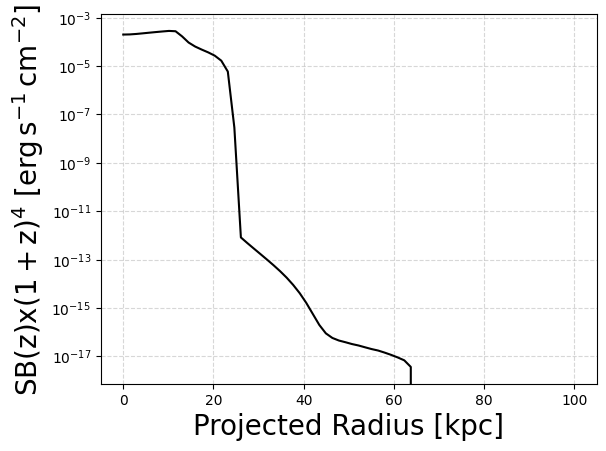

In [23]:
Lumin_435 =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
Lumin_455 = 45.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
cloudy_path_435_24 = CLOUDY_path(Lumin_435,idx_2,metals,Column_density_order)
cloudy_data_435_24 = CLOUDY_data_path(cloudy_path_435_24)

cloudy_path_455_24 = CLOUDY_path(Lumin_455,idx_2,metals,Column_density_order)
cloudy_data_455_24 = CLOUDY_data_path(cloudy_path_455_24)

atom = 'CIV'
# print(cloudy_data_435_24[f'SB_{atom}'])
plt.plot(cloudy_data_435_24[f'radius_p'],cloudy_data_435_24[f'SB_{atom}'],'k-')
plt.yscale('log')


plt.grid(True,linestyle='--',alpha=0.5)
plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)

(np.float64(3.8553519384357046e-07), 0.001)

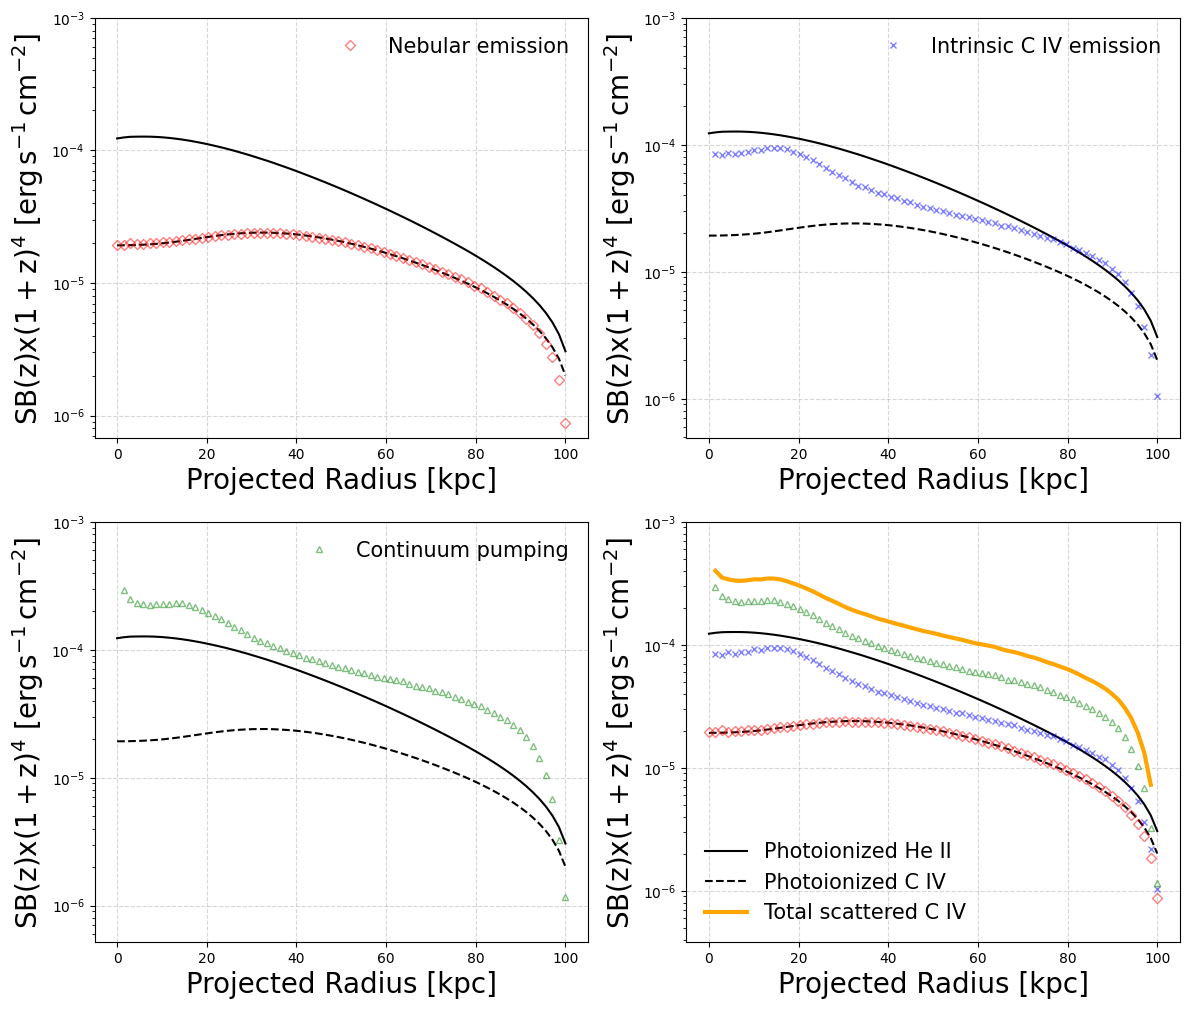

In [24]:
fig = plt.figure(1,figsize=(14,12))
Lumin = 45.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 500
V_emit = 3000
V_rand = 30



plt.subplot(221)
geo = "Nebula"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--')
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label='Nebular emission')

# print()


plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(222)
geo = "QSO"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--')
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label='Intrinsic C IV emission')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(223)
geo = "Continuum"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--')
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label='Continuum pumping')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(224)
geo = "Nebula"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',alpha=1.0,label='Photoionized He II')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',alpha=1.0,label='Photoionized C IV ')
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],'-',color='orange',alpha=1.0,lw=3,label='Total scattered C IV')

geo = "Nebula"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,)

geo = "QSO"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5)

geo = "Continuum"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5)


plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_455_M_0100_V_500', bbox_inches='tight')

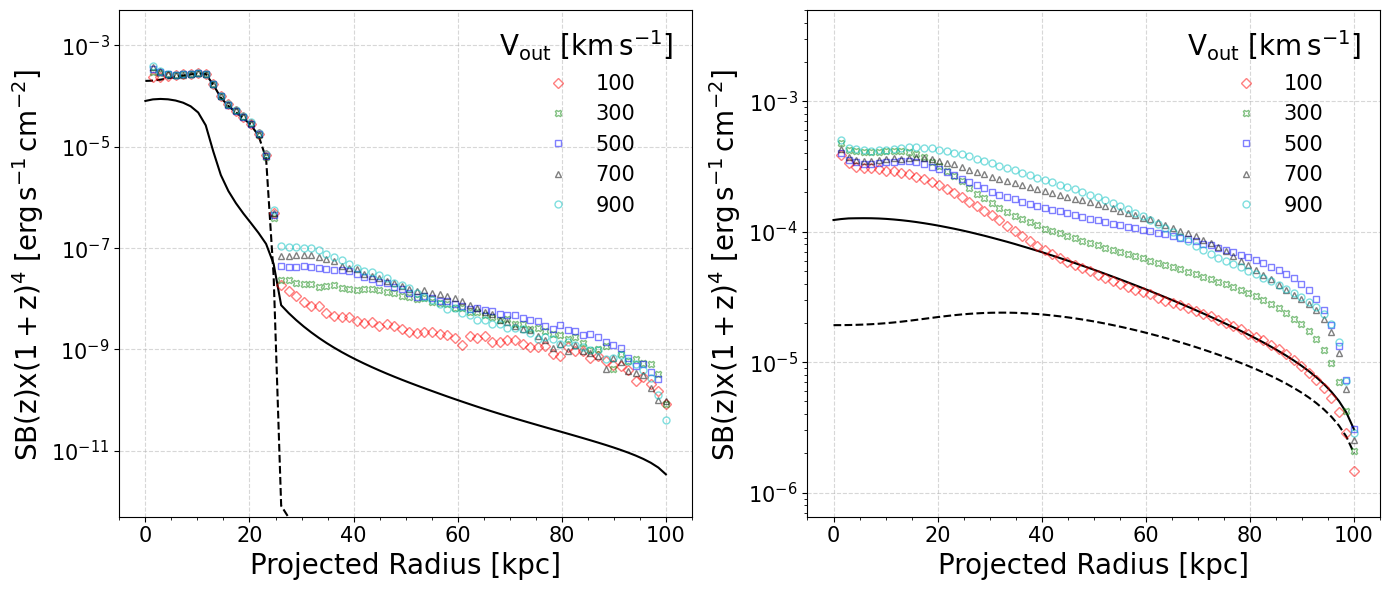

In [25]:
fig = plt.figure(1,figsize=(14,6))

plt.subplot(121)
Lumin = 43.5
metals = 0.1
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--')
# plt.legend(title="Photoionization Model")
# plt.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.2,color='y')
# plt.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.2,color='m')

geo = "Nebula"
V_out = 100
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 300
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 500
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 700
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 900
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='o',color='c',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')


leg = plt.legend(title=r"$\rm V_{\rm out}~[ \rm km \, s^{-1}]$", title_fontsize=20,fontsize=15, frameon=False)
# leg.get_frame().set_alpha(0.5)
# plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# plt.axvline(x=16.5,ymin=0,ymax=1,linestyle=\rm'-',color='gray',alpha=0.6,lw=5)

# print()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.yscale('log')
plt.minorticks_on()



plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=5e-3,ymin=5e-13)

plt.subplot(122)
Lumin = 45.5 

plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--')

geo = "Nebula"
V_out = 100
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 300
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 500
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 700
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')

V_out = 900
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='o',color='c',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'{V_out}')


# plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

plt.yscale('log')

leg = plt.legend(title=r"$\rm V_{\rm out}~[ \rm km \, s^{-1}]$", title_fontsize=20,fontsize=15, frameon=False)
# leg.get_frame().set_alpha(0.5)

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=5e-3)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.minorticks_on()

plt.tight_layout()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Spatial_Distribution.pdf', bbox_inches='tight')

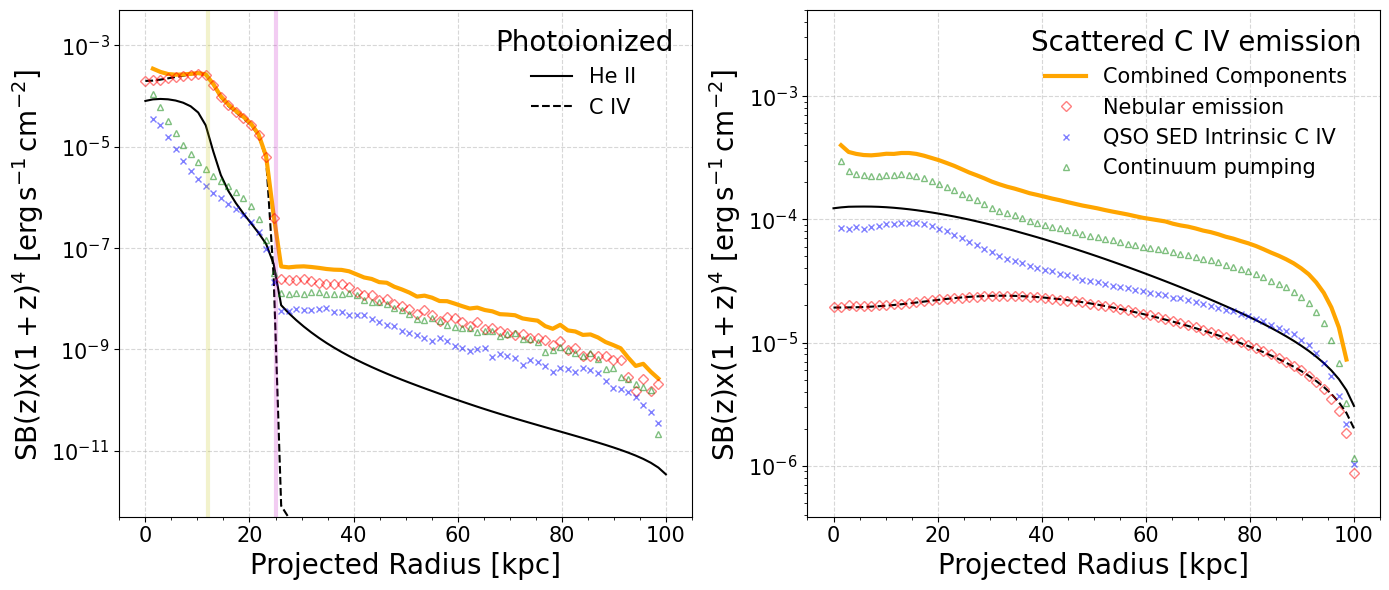

In [26]:
fig = plt.figure(1,figsize=(14,6))
Lumin = 43.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 500
V_emit = 3000
V_rand = 30


plt.subplot(121)
geo = "Nebula"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',alpha=1.0,label='He II')
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',alpha=1.0,label='C IV ')
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],'-',color='orange',alpha=1.0,lw=3)

geo = "Nebula"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,)
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],'r-.',lw=2,alpha=0.5,)


geo = "QSO"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5)
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],'b-.',lw=2,alpha=0.5,)


geo = "Continuum"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5)
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],'g-.',lw=2,alpha=0.5,)

plt.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.2,color='y')
plt.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.2,color='m')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15,title='Photoionized',title_fontsize=20)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
plt.ylim(ymax=5e-3,ymin=5e-13)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.minorticks_on()

plt.subplot(122)
Lumin = 45.5
geo = "Nebula"
plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',alpha=1.0)
plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',alpha=1.0)
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],'-',color='orange',alpha=1.0,lw=3,label='Combined Components')
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='o',color='y',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label='Combine components')



geo = "Nebula"

plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label='Nebular emission')

geo = "QSO"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label='QSO SED Intrinsic C IV')


geo = "Continuum"
plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'SB_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label='Continuum pumping')


# print(np.sum(Tot))


plt.yscale('log')

plt.legend(frameon=False,fontsize=15,title='Scattered C IV emission',title_fontsize=20)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.ylim(ymax=5e-3)
plt.minorticks_on()


plt.tight_layout()
# plt.ylim(ymin=1e-6)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Components_scattering.pdf', bbox_inches='tight')

In [27]:
# fig = plt.figure(1,figsize=(14,10))
# Lumin = 45.5 
# plt.subplot(221)
# metals=0.001
# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# odot = r'\odot'

# V_out = 100
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 300
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 500
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 700
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend(title=f'$Z = {metals} Z_{{{odot}}}$')

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)

# plt.subplot(222)
# metals=0.01
# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# odot = r'\odot'

# V_out = 100
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 300
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 500
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 700
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend(title=f'$Z = {metals} Z_{{{odot}}}$')

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)


# plt.subplot(223)
# metals=0.1
# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# odot = r'\odot'

# V_out = 100
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 300
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 500
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 700
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend(title=f'$Z = {metals} Z_{{{odot}}}$')

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)

# plt.subplot(224)
# metals=1.0
# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# odot = r'\odot'

# V_out = 100
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 300
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 500
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# V_out = 700
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'Vout = {V_out} km/s')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend(title=f'$Z = {metals} Z_{{{odot}}}$')

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Metallicity', bbox_inches='tight')

In [28]:
# fig = plt.figure(1,figsize=(14,5))
# Lumin = 44.0 
# plt.subplot(121)
# metals=1.0
# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# V_out = 500
# odot = r'\odot'

# metals=0.001
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=0.01
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=0.1
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=1.0
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend()

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)

# plt.subplot(122)
# Lumin = 45.5 

# plt.plot(globals()[f'radius_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_HeII_{Lumin}_{metals}_{Column_density_order}'],'k-',label='He II')
# plt.plot(globals()[f'radius_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'], globals()[f'SB_Test_WO_LT_CIV_{Lumin}_{metals}_{Column_density_order}'],'k--',label='C IV')

# geo = "Nebula"
# V_out = 500
# odot = r'\odot'

# metals=0.001
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=0.01
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='X',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=0.1
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='s',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# metals=1.0
# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'],marker='^',color='k',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=f'$Z = {metals} Z_{{{odot}}}$')

# # plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# # plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.yscale('log')

# plt.legend()

# plt.grid(True,linestyle='--',alpha=0.5)

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymax=1e-3)

